In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Dict, Any

In [2]:
class AgentState(TypedDict):
    query: str
    query_id: str

In [3]:
def _planner(s: AgentState):
    pass

def _budget_check(s: AgentState):
    pass

def tool_node(s: AgentState):
    pass

def _reflector(s: AgentState):
    pass
def _terminate(s: AgentState):
    pass
def _simple_response_node(s: AgentState):
    pass
def human_review_node(s: AgentState):
    pass

def route_after_planner(s: AgentState):
    pass

def route_after_review(s: AgentState):
    pass
def route_after_budget(s: AgentState):
    pass
def route_after_reflector(s: AgentState) :
    pass

In [4]:
g = StateGraph(AgentState)
g.add_node("planner",      _planner)
g.add_node("budget_check", _budget_check)
g.add_node("tools",        tool_node)
g.add_node("reflector",    _reflector)
g.add_node("terminate",    _terminate)
g.add_node("simple_response", _simple_response_node)
g.add_node("human_review", human_review_node)

g.set_entry_point("planner")
g.add_conditional_edges(
    "planner", route_after_planner,
    ["human_review", "simple_response"]
)

g.add_edge("simple_response", END)
g.add_conditional_edges(
    "human_review", route_after_review,
    [ "budget_check",  "planner"],
)

g.add_conditional_edges(
    "budget_check", route_after_budget,
    ["tools", "terminate"],
)
g.add_edge("tools", "reflector")


g.add_conditional_edges(
    "reflector", route_after_reflector,
    ["planner", "terminate"]
)
g.add_edge("terminate", END)

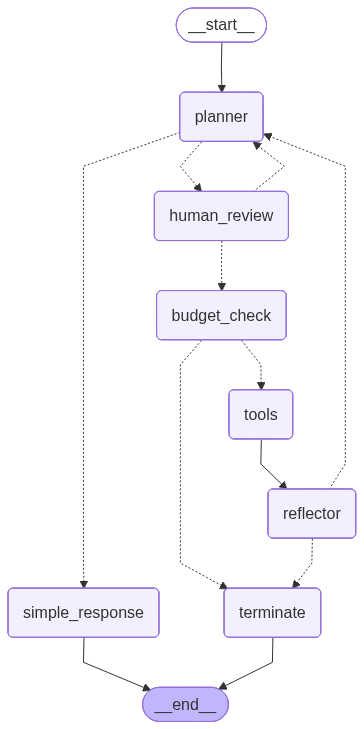

In [5]:
g.compile()

In [8]:
#New Graph
g = StateGraph(AgentState)
g.add_node("planner",      _planner)
g.add_node("budget_check", _budget_check)
g.add_node("tools",        tool_node)

g.add_node("terminate", _terminate)
g.add_node("human_review", human_review_node)

g.set_entry_point("planner")
g.add_conditional_edges(
    "planner", route_after_planner,
    ["human_review", "terminate"]
)


g.add_conditional_edges(
    "human_review", route_after_review,
    [ "budget_check",  "planner"],
)

g.add_conditional_edges(
    "budget_check", route_after_budget,
    ["tools", "terminate"],
)
g.add_edge("tools", "planner")

g.add_edge("terminate", END)


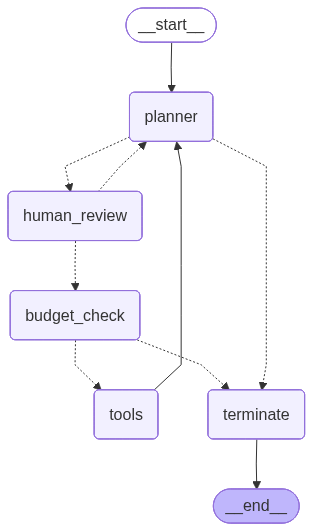

In [9]:
g.compile()